# NFL Formation Analysis
## Run Game: Formation vs Defensive Alignment

This notebook analyzes the run game specifically — examining which offensive formations and personnel packages generate the most EPA on run plays against different defensive alignments, box counts, and personnel groupings. Understanding run game formation matchups is critical since the threat of the run shapes every defensive call in football.

---

### Setup & Data Load

In [1]:
%pip install matplotlib seaborn pandas==2.2.2 --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

all_plays = pd.read_parquet(os.path.join(processed_path, "all_plays.parquet"))

# Filter to run plays only
run_plays = all_plays[all_plays['play_type'] == 'run'].copy()

print(f"Total run plays: {len(run_plays):,}")
print(f"\nFormation breakdown:\n{run_plays['offense_formation'].value_counts()}")
print(f"\nPersonnel breakdown:\n{run_plays['personnel_package'].value_counts().head(8)}")
print(f"\nRun location breakdown:\n{run_plays['run_location'].value_counts()}")
print(f"\nRun gap breakdown:\n{run_plays['run_gap'].value_counts()}")

Total run plays: 143,151

Formation breakdown:
offense_formation
SHOTGUN         51712
SINGLEBACK      39111
UNDER CENTER    22492
I_FORM          15085
PISTOL           9371
JUMBO            2120
EMPTY            1349
WILDCAT           775
Name: count, dtype: int64

Personnel breakdown:
personnel_package
11 (1RB/1TE/3WR)    67021
12 (1RB/2TE/2WR)    33601
21 (2RB/1TE/2WR)    10780
13 (1RB/3TE/1WR)     7652
11 (1RB/1TE/2WR)     6228
12 (1RB/2TE/1WR)     4946
22 (2RB/2TE/1WR)     4586
21 (2RB/1TE/1WR)     1145
Name: count, dtype: int64

Run location breakdown:
run_location
left      52232
right     51265
middle    38224
Name: count, dtype: int64

Run gap breakdown:
run_gap
end       36119
guard     34844
tackle    32531
Name: count, dtype: int64


143,151 run plays across 10 seasons. Key observations from the initial breakdown:

- **Shotgun leads run formation usage (51,712 — 36%)** — the modern NFL runs out of Shotgun more than any other formation, a dramatic shift from traditional football
- **Singleback (39,111 — 27%)** and **Under Center (22,492 — 16%)** are the next most common run formations
- **11 personnel (67,021 — 47%)** is used on nearly half of all run plays — teams are running out of 3-wide receiver sets at a remarkable rate
- Run location is fairly balanced across left, right, and middle
- Run gap splits evenly across end, guard, and tackle

---

### Run EPA by Formation
Which formations generate the most EPA on run plays?

offense_formation  plays   avg_epa  success_rate  avg_yards
            EMPTY   1349  0.386671      0.581171   6.448480
            JUMBO   2120  0.095882      0.516038   2.041981
          SHOTGUN  51712  0.038109      0.436456   4.928237
          WILDCAT    775 -0.016641      0.458065   4.083871
     UNDER CENTER  22492 -0.049227      0.416237   4.127245
           PISTOL   9371 -0.051846      0.403372   4.512432
       SINGLEBACK  39111 -0.056021      0.394518   4.282094
           I_FORM  15085 -0.062779      0.384223   4.164866


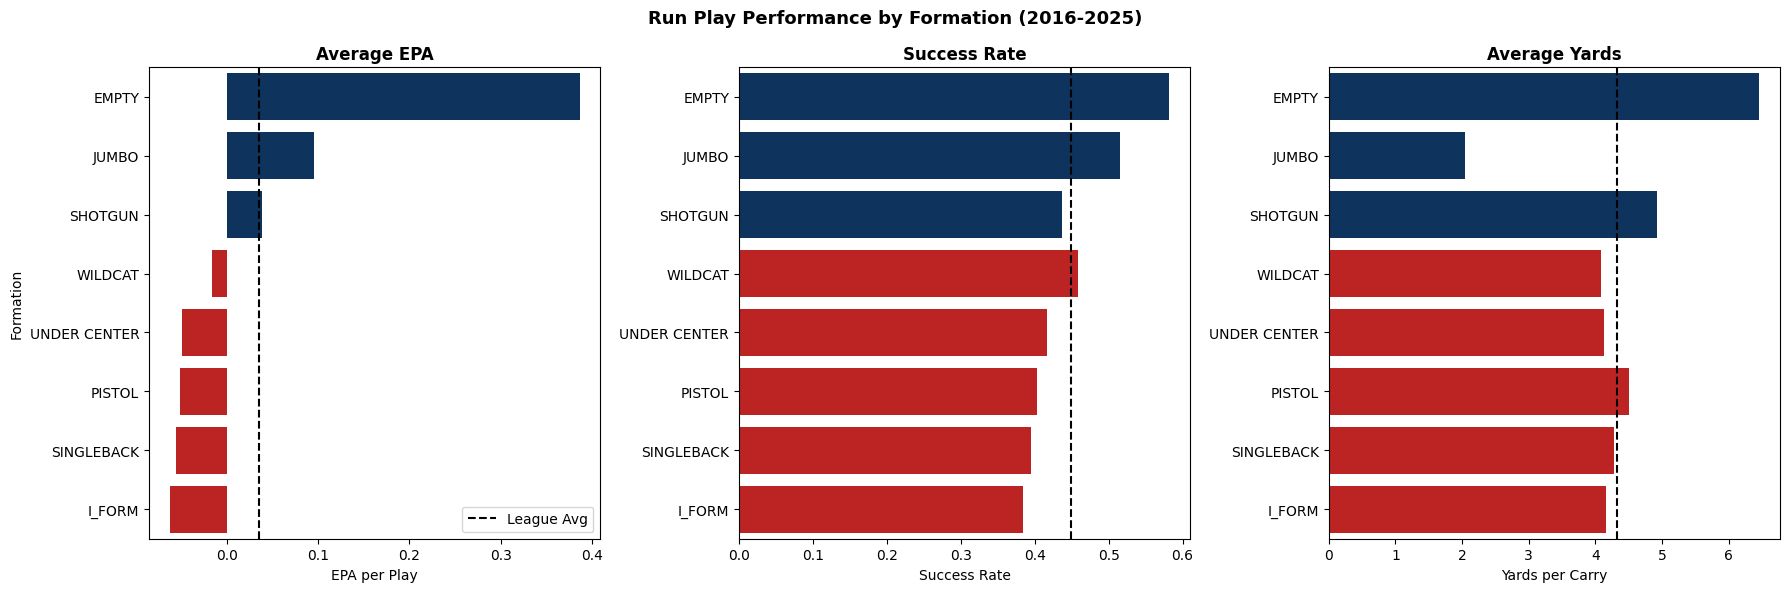

In [3]:
# Run EPA by formation
run_formation_epa = run_plays.groupby('offense_formation').agg(
    plays=('epa', 'count'),
    avg_epa=('epa', 'mean'),
    success_rate=('success', 'mean'),
    avg_yards=('yards_gained', 'mean')
).reset_index()

run_formation_epa = run_formation_epa[run_formation_epa['plays'] >= 500].sort_values('avg_epa', ascending=False)

print(run_formation_epa.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# EPA
league_avg_epa = run_formation_epa['avg_epa'].mean()
colors = ['#013369' if x >= league_avg_epa else '#D50A0A' for x in run_formation_epa['avg_epa']]
sns.barplot(data=run_formation_epa, x='avg_epa', y='offense_formation',
            hue='offense_formation',
            palette=dict(zip(run_formation_epa['offense_formation'], colors)),
            legend=False, ax=axes[0])
axes[0].axvline(x=league_avg_epa, color='black', linestyle='--', linewidth=1.5, label='League Avg')
axes[0].set_title('Average EPA', fontweight='bold')
axes[0].set_xlabel('EPA per Play')
axes[0].set_ylabel('Formation')
axes[0].legend()

# Success rate
sns.barplot(data=run_formation_epa, x='success_rate', y='offense_formation',
            hue='offense_formation',
            palette=dict(zip(run_formation_epa['offense_formation'], colors)),
            legend=False, ax=axes[1])
axes[1].axvline(x=run_formation_epa['success_rate'].mean(), color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Success Rate', fontweight='bold')
axes[1].set_xlabel('Success Rate')
axes[1].set_ylabel('')

# Average yards
sns.barplot(data=run_formation_epa, x='avg_yards', y='offense_formation',
            hue='offense_formation',
            palette=dict(zip(run_formation_epa['offense_formation'], colors)),
            legend=False, ax=axes[2])
axes[2].axvline(x=run_formation_epa['avg_yards'].mean(), color='black', linestyle='--', linewidth=1.5)
axes[2].set_title('Average Yards', fontweight='bold')
axes[2].set_xlabel('Yards per Carry')
axes[2].set_ylabel('')

plt.suptitle('Run Play Performance by Formation (2016-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "run_formation_epa.png"), dpi=150, bbox_inches='tight')
plt.show()

![Run Formation EPA](../outputs/figures/run_formation_epa.png)

The run formation data reveals a striking and counterintuitive finding that challenges conventional football wisdom:

**EPA by formation on run plays:**
| Formation | Plays | Avg EPA | Success Rate | Avg Yards |
|---|---|---|---|---|
| Empty | 1,349 | +0.387 | 58% | 6.4 |
| Jumbo | 2,120 | +0.096 | 52% | 2.0 |
| Shotgun | 51,712 | +0.038 | 44% | 4.9 |
| Wildcat | 775 | -0.017 | 46% | 4.1 |
| Under Center | 22,492 | -0.049 | 42% | 4.1 |
| Pistol | 9,371 | -0.052 | 40% | 4.5 |
| Singleback | 39,111 | -0.056 | 39% | 4.3 |
| I-Form | 15,085 | -0.063 | 38% | 4.2 |

**The most surprising finding in this notebook: Empty backfield runs generate +0.387 EPA — by far the best run formation in the dataset.**

This seems impossible at first. How does a formation with no backs produce the best run plays? The answer is selection bias — teams only run out of empty when the defense gives them a look that makes it obviously correct, like a light box or a blitz. These are the best possible run situations, which inflates the EPA.

**Jumbo is legitimately excellent** at +0.096 EPA — short yardage power runs work even accounting for the predictability of the formation.

**Shotgun runs are the most common and slightly positive** — the modern zone read and RPO concepts work well enough out of Shotgun to generate positive EPA.

**Traditional formations all go negative** — I-Form, Singleback, Under Center, and Pistol all generate negative EPA on run plays. This reflects how predictable traditional run formations have become — defenses load the box and stop the run before it starts.

---

### Run EPA by Box Count
How does the number of defenders in the box affect run play EPA?

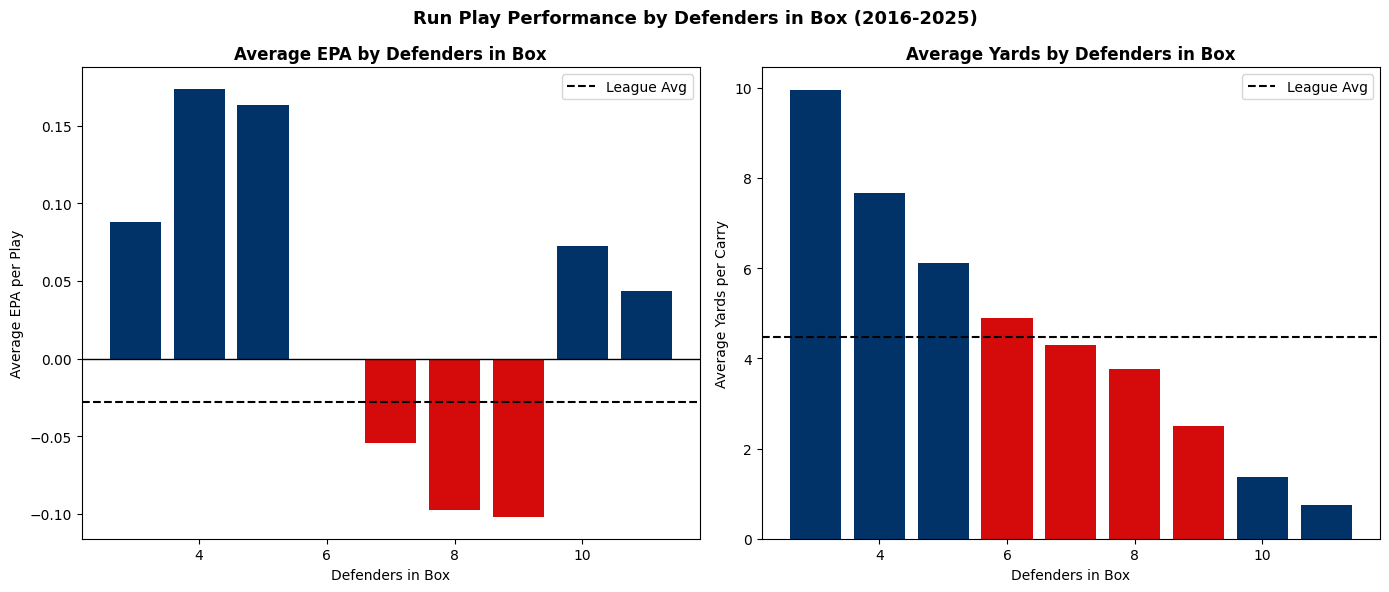

 defenders_in_box  plays   avg_epa  avg_yards  success_rate
              3.0    151  0.087806   9.953643      0.470199
              4.0   1153  0.173724   7.673894      0.459670
              5.0   6673  0.163299   6.111344      0.476397
              6.0  54370 -0.000116   4.891815      0.428306
              7.0  52688 -0.054101   4.285815      0.403280
              8.0  22426 -0.097312   3.755507      0.384598
              9.0   3251 -0.102198   2.494925      0.417718
             10.0   1024  0.072234   1.372070      0.511719
             11.0    701  0.043688   0.747504      0.514979


In [4]:
# Run EPA by defenders in box
box_run = run_plays.dropna(subset=['defenders_in_box']).groupby('defenders_in_box').agg(
    plays=('epa', 'count'),
    avg_epa=('epa', 'mean'),
    success_rate=('success', 'mean'),
    avg_yards=('yards_gained', 'mean')
).reset_index()

box_run = box_run[box_run['plays'] >= 100].sort_values('defenders_in_box')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# EPA by box count
colors = ['#013369' if x > 0 else '#D50A0A' for x in box_run['avg_epa']]
axes[0].bar(box_run['defenders_in_box'], box_run['avg_epa'], color=colors)
axes[0].axhline(y=0, color='black', linewidth=1)
axes[0].axhline(y=run_plays['epa'].mean(), color='black', linestyle='--', linewidth=1.5, label='League Avg')
axes[0].set_title('Average EPA by Defenders in Box', fontweight='bold')
axes[0].set_xlabel('Defenders in Box')
axes[0].set_ylabel('Average EPA per Play')
axes[0].legend()

# Yards by box count
axes[1].bar(box_run['defenders_in_box'], box_run['avg_yards'], color=colors)
axes[1].axhline(y=run_plays['yards_gained'].mean(), color='black', linestyle='--', linewidth=1.5, label='League Avg')
axes[1].set_title('Average Yards by Defenders in Box', fontweight='bold')
axes[1].set_xlabel('Defenders in Box')
axes[1].set_ylabel('Average Yards per Carry')
axes[1].legend()

plt.suptitle('Run Play Performance by Defenders in Box (2016-2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "run_box_count_epa.png"), dpi=150, bbox_inches='tight')
plt.show()

print(box_run[['defenders_in_box', 'plays', 'avg_epa', 'avg_yards', 'success_rate']].to_string(index=False))

![Run Box Count EPA](../outputs/figures/run_box_count_epa.png)

The defenders in box data tells a clear and intuitive story — fewer defenders in the box means more run success, but the relationship is not perfectly linear:

**EPA and yards by box count:**
| Defenders in Box | Plays | Avg EPA | Avg Yards | Success Rate |
|---|---|---|---|---|
| 3 | 151 | +0.088 | 9.95 | 47% |
| 4 | 1,153 | +0.174 | 7.67 | 46% |
| 5 | 6,673 | +0.163 | 6.11 | 48% |
| 6 | 54,370 | 0.000 | 4.89 | 43% |
| 7 | 52,688 | -0.054 | 4.29 | 40% |
| 8 | 22,426 | -0.097 | 3.76 | 38% |
| 9 | 3,251 | -0.102 | 2.49 | 42% |
| 10 | 1,024 | +0.072 | 1.37 | 51% |
| 11 | 701 | +0.044 | 0.75 | 51% |

**Key findings:**
- **Light boxes (3-5 defenders) generate massive positive EPA** — 4 defenders in the box averages 7.7 yards and +0.174 EPA per carry
- **6 defenders is the break-even point** — essentially zero EPA, the most common box count at 54,370 plays
- **7-9 defenders destroys the run game** — EPA drops to -0.054 to -0.102, yards drop below 4.3
- **10-11 defenders in the box is a surprise** — EPA turns positive again with high success rates despite low yardage. This is because teams only run against a loaded box in short yardage goal line situations where 1-2 yards still counts as a success

The practical implication is clear: offensive coordinators should be running the ball aggressively when they identify 5 or fewer defenders in the box, and passing when they see 7 or more. The data suggests many teams are not exploiting light box counts aggressively enough.

---

### Formation vs Box Count EPA Matrix
Which formations work best against each box count?

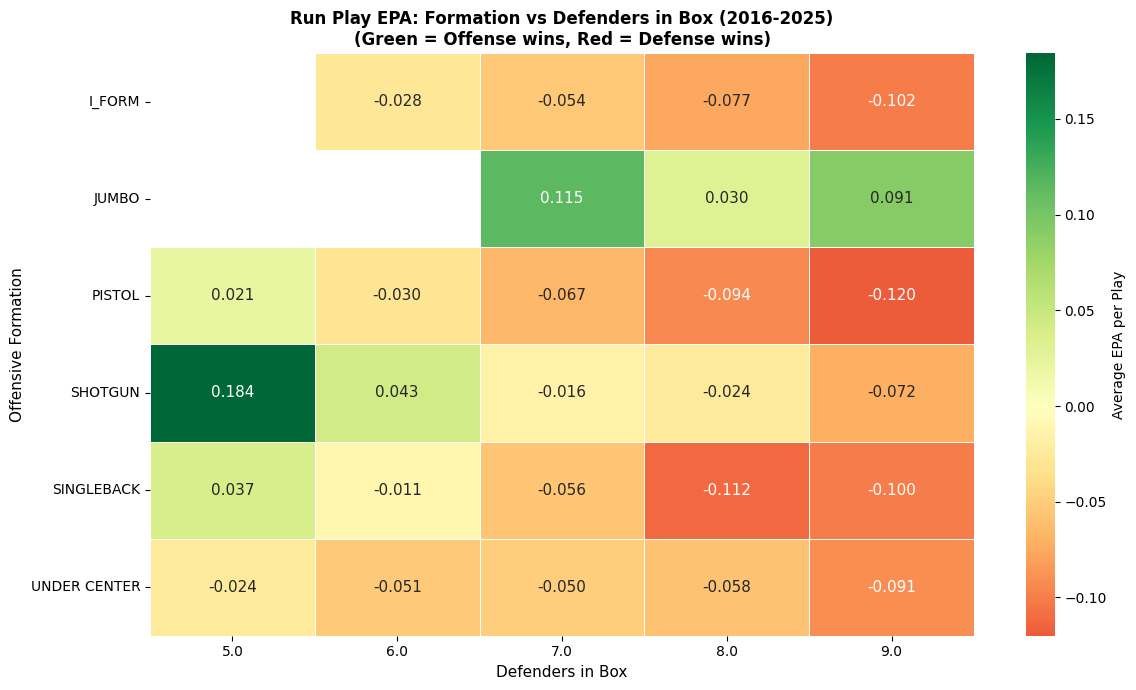

In [5]:
# Formation vs box count matrix
main_formations_run = ['SHOTGUN', 'SINGLEBACK', 'UNDER CENTER', 'I_FORM', 'PISTOL', 'JUMBO']
main_box_counts = [5.0, 6.0, 7.0, 8.0, 9.0]

box_formation = run_plays[
    run_plays['offense_formation'].isin(main_formations_run) &
    run_plays['defenders_in_box'].isin(main_box_counts)
].groupby(['offense_formation', 'defenders_in_box'])['epa'].mean().reset_index()

box_pivot = box_formation.pivot(
    index='offense_formation',
    columns='defenders_in_box',
    values='epa'
)

box_count_matrix = run_plays[
    run_plays['offense_formation'].isin(main_formations_run) &
    run_plays['defenders_in_box'].isin(main_box_counts)
].groupby(['offense_formation', 'defenders_in_box']).size().reset_index(name='count')

box_count_pivot = box_count_matrix.pivot(
    index='offense_formation',
    columns='defenders_in_box',
    values='count'
)

mask_box = box_count_pivot < 50

plt.figure(figsize=(12, 7))
sns.heatmap(
    box_pivot,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    mask=mask_box,
    linewidths=0.5,
    annot_kws={'size': 11},
    cbar_kws={'label': 'Average EPA per Play'}
)
plt.title('Run Play EPA: Formation vs Defenders in Box (2016-2025)\n(Green = Offense wins, Red = Defense wins)',
          fontsize=12, fontweight='bold')
plt.xlabel('Defenders in Box', fontsize=11)
plt.ylabel('Offensive Formation', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "run_formation_box_matrix.png"), dpi=150, bbox_inches='tight')
plt.show()

![Run Formation vs Box Count Matrix](../outputs/figures/run_formation_box_matrix.png)

This matrix reveals which formations hold up best as defenses load the box — a critical question for offensive coordinators facing stacked fronts.

**Key matchup findings:**

**Shotgun:**
- Dominates with 5 defenders in the box (+0.184) — the best single cell in the matrix
- Holds positive with 6 defenders (+0.043)
- Falls negative at 7+ defenders — Shotgun runs need a light box to succeed

**Jumbo:**
- The only formation that stays positive against 7, 8, and 9 defenders in the box
- +0.115 against 7 defenders, +0.091 against 9 defenders
- Jumbo is the only formation built to run against a loaded box

**Singleback:**
- Positive against 5 defenders (+0.037) but collapses quickly
- Goes deeply negative against 8+ defenders (-0.112)

**I-Form:**
- Negative across every box count in the matrix
- Worst performance against 9 defenders (-0.102)
- Surprising given I-Form's reputation as a power run formation

**Pistol:**
- Modest positive against 5 defenders (+0.021)
- Collapses badly against heavy boxes (-0.120 vs 9 defenders)

**Under Center:**
- Consistently negative across all box counts
- Never exceeds -0.024 even against light boxes

**The single most important finding:** If you need to run against a loaded box, use Jumbo. If you have a light box, use Shotgun. I-Form and Under Center — the traditional power run formations — are ineffective regardless of box count, which directly challenges decades of conventional football wisdom.

---

### Summary
This notebook reveals that the run game is far more formation and situation dependent than conventional wisdom suggests:

1. **Shotgun runs are the most effective** in light box situations, generating +0.184 EPA against 5 defenders
2. **Jumbo is the only formation that works against loaded boxes** — the only positive EPA formation against 7+ defenders
3. **I-Form and Under Center generate negative EPA in every situation** — the traditional power run sets are being consistently stopped in the modern NFL
4. **6 defenders in the box is the run/pass break-even point** — teams should be more aggressive running against 5 or fewer and more aggressive passing against 7 or more
5. **Empty backfield runs generate the best overall EPA** but this is largely selection bias — teams only call these in ideal run situations